In [2]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/4th yr/ImageDataset"

Mounted at /content/drive


In [3]:
import os
import tensorflow as tf

def strict_clean_dataset(path):
    print(f"Strict cleaning dataset at: {path}")
    count = 0
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.startswith('.') or file.lower().endswith(('.txt', '.csv', '.db')):
                os.remove(os.path.join(root, file))
                continue

            file_path = os.path.join(root, file)
            try:
                img_bytes = tf.io.read_file(file_path)
                tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
            except Exception as e:
                print(f"Deleting incompatible file: {file_path}")
                os.remove(file_path)
                count += 1
    print(f"Removed {count} problematic files. Please re-run the Data Loading cell (ru4W0Er-cR0u) now.")

strict_clean_dataset(dataset_path)

Strict cleaning dataset at: /content/drive/MyDrive/4th yr/ImageDataset
Removed 0 problematic files. Please re-run the Data Loading cell (ru4W0Er-cR0u) now.


In [4]:
import tensorflow as tf

img_height, img_width = 224, 224  # pre-trained models expect 224×224
batch_size = 32

# Training split (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Validation split (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Num classes:", len(class_names))

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 7188 files belonging to 20 classes.
Using 5751 files for training.
Found 7188 files belonging to 20 classes.
Using 1437 files for validation.
Classes: ['ARATILES', 'AVOCADO', 'Baobab (Adansonia digitata)', 'Breadfruit Tree (Artocarpus altilis)', 'COCOA', 'Cedar of Lebanon (Cedrus libani)', 'DUHAT', 'Dragon Blood Tree', 'Eucalyptus', 'GUAVA', 'KAMIAS', 'Kapur Tree (Dryobalanops aromatica)', 'LANGKA', 'LANZONES', 'MANGOSTEEN', 'Monkey Pod Tree (Samanea saman)', 'PAPAYA', 'RAMBUTAN', 'Soursop Tree (Annona muricata)', 'Wollemi Pine (Wollemia nobilis)']
Num classes: 20


In [5]:
from tensorflow.keras import layers, models

def build_model(base_model):
    base_model.trainable = False  # Freeze pre-trained weights

    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),    # Replaces Flatten — fewer params
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(class_names))     # Output: one neuron per class
    ])
    return model

In [6]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50

models_dict = {
    "MobileNetV2":   MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "EfficientNetB0": EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "ResNet50":       ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3)),
}

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras import layers, models
import tensorflow as tf

# ── Preprocessing map ──────────────────────────────────────
preprocess_map = {
    "MobileNetV2":    mob_pre,
    "EfficientNetB0": eff_pre,
    "ResNet50":       res_pre,
}

# ── Fixed build_model (no more Rescaling conflict) ─────────
def build_model(base_model, preprocess_fn):
    base_model.trainable = False
    model = models.Sequential([
        layers.Lambda(lambda x: preprocess_fn(x), input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(class_names))
    ])
    return model

# ── Training loop (only 1 line changed inside) ─────────────
tf.keras.backend.clear_session()

histories = {}
trained_models = {}

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for name, base in models_dict.items():
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    try:
        model = build_model(base, preprocess_map[name])  # ← only change in the loop
        model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy']
        )
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=10,
            callbacks=[early_stop]
        )
        histories[name] = history
        trained_models[name] = model
        model.save(f"/content/drive/MyDrive/4th yr/{name}_model.keras")
        print(f"Saved: {name}_model.keras")
    except Exception as e:
        print(f"Error training {name}: {e}")


Training: MobileNetV2
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


180/180 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.1617 - loss: 2.8558 - val_accuracy: 0.4050 - val_loss: 2.3652
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.3780 - loss: 2.1917 - val_accuracy: 0.6298 - val_loss: 1.7479
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.5220 - loss: 1.7401 - val_accuracy: 0.7063 - val_loss: 1.3566
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.6171 - loss: 1.4125 - val_accuracy: 0.7794 - val_loss: 1.1039
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.6874 - loss: 1.1901 - val_accuracy: 0.8288 - val_loss: 0.9165
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.7428 - loss: 1.0043 - val_accuracy: 0.8643 - val_loss: 0.7738
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7806 - loss: 0.8847 - val_accuracy: 0.8894 - val_loss: 0.6627
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.8087 - loss: 0.7765 - val_accuracy: 0.910

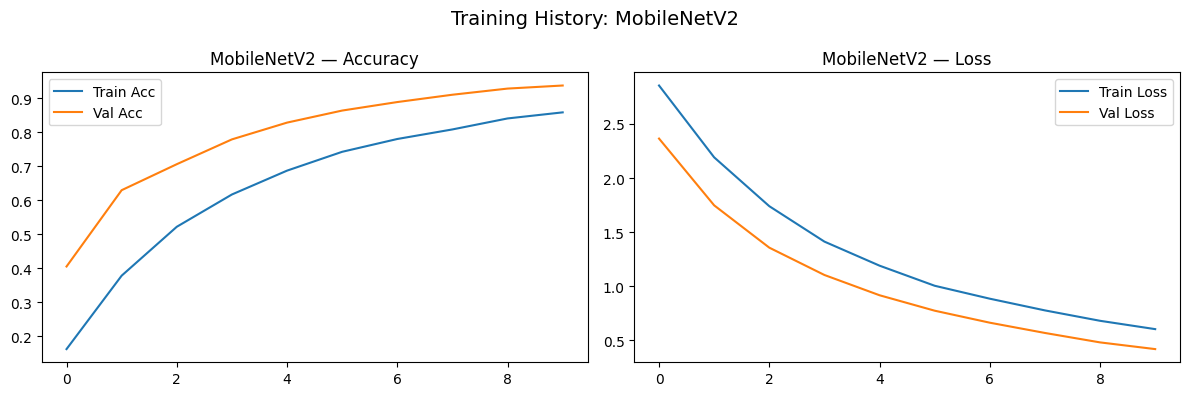

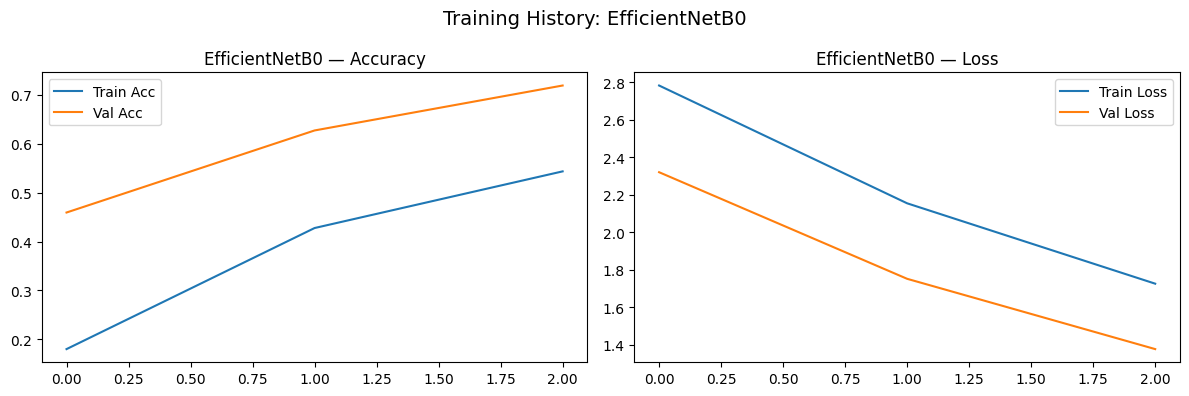

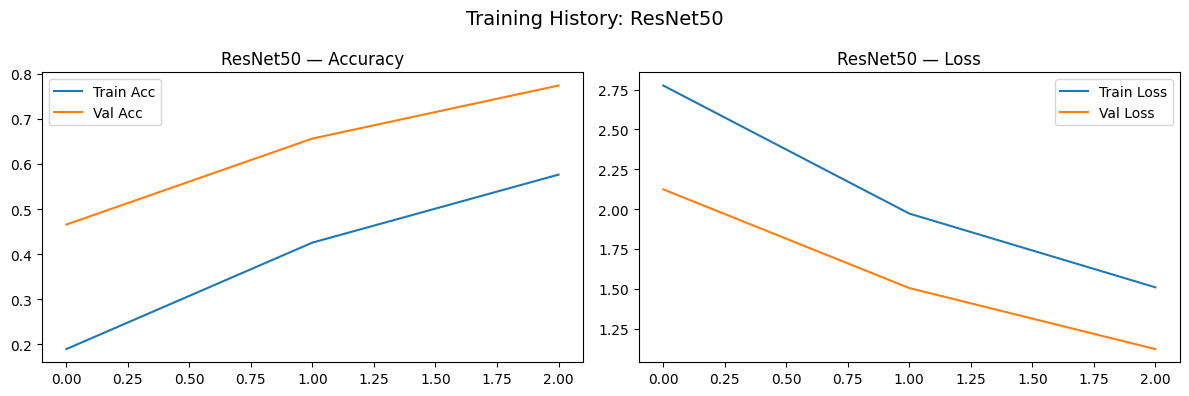

In [12]:
import matplotlib.pyplot as plt

for name, history in histories.items():
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.legend(); plt.title(f'{name} — Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(); plt.title(f'{name} — Loss')

    plt.suptitle(f'Training History: {name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/4th yr/{name}_training_curves.png")
    plt.show()

In [13]:
from sklearn.metrics import classification_report
import numpy as np

def evaluate_model(model, name):
    y_true, y_pred, y_prob = [], [], []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
        y_prob.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    print(f"\n=== Classification Report: {name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return y_true, y_pred, y_prob

# Run for all trained models
results = {}
for name, model in trained_models.items():
    y_true, y_pred, y_prob = evaluate_model(model, name)
    results[name] = {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}


=== Classification Report: MobileNetV2 ===
                                      precision    recall  f1-score   support

                            ARATILES       1.00      0.94      0.97        67
                             AVOCADO       0.99      0.88      0.93        76
         Baobab (Adansonia digitata)       0.97      0.92      0.94        61
Breadfruit Tree (Artocarpus altilis)       0.96      0.94      0.95        53
                               COCOA       0.94      0.94      0.94        81
    Cedar of Lebanon (Cedrus libani)       0.88      0.96      0.91        90
                               DUHAT       1.00      0.82      0.90        82
                   Dragon Blood Tree       0.98      1.00      0.99        47
                          Eucalyptus       0.88      0.96      0.92        78
                               GUAVA       0.90      0.91      0.91        82
                              KAMIAS       1.00      0.96      0.98        78
 Kapur Tree (Dryoba

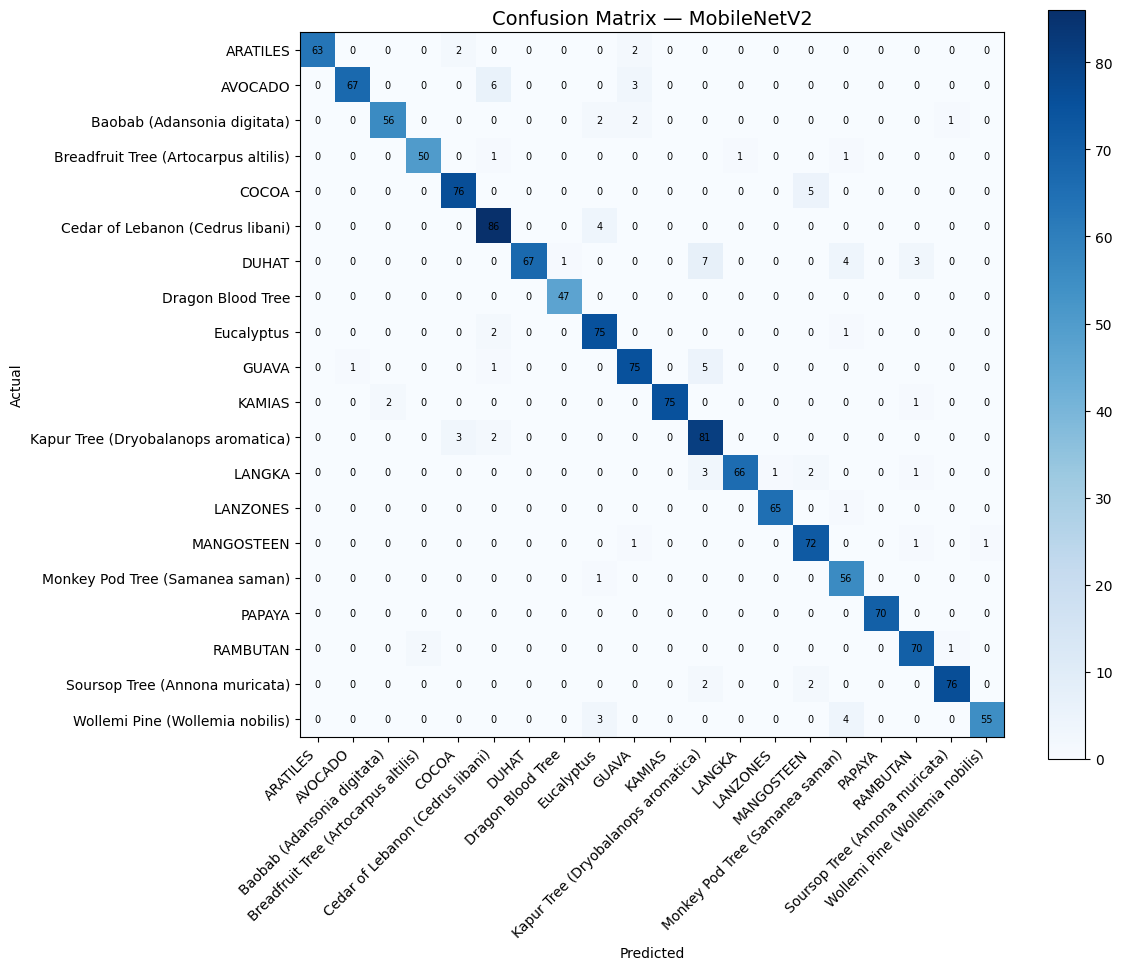

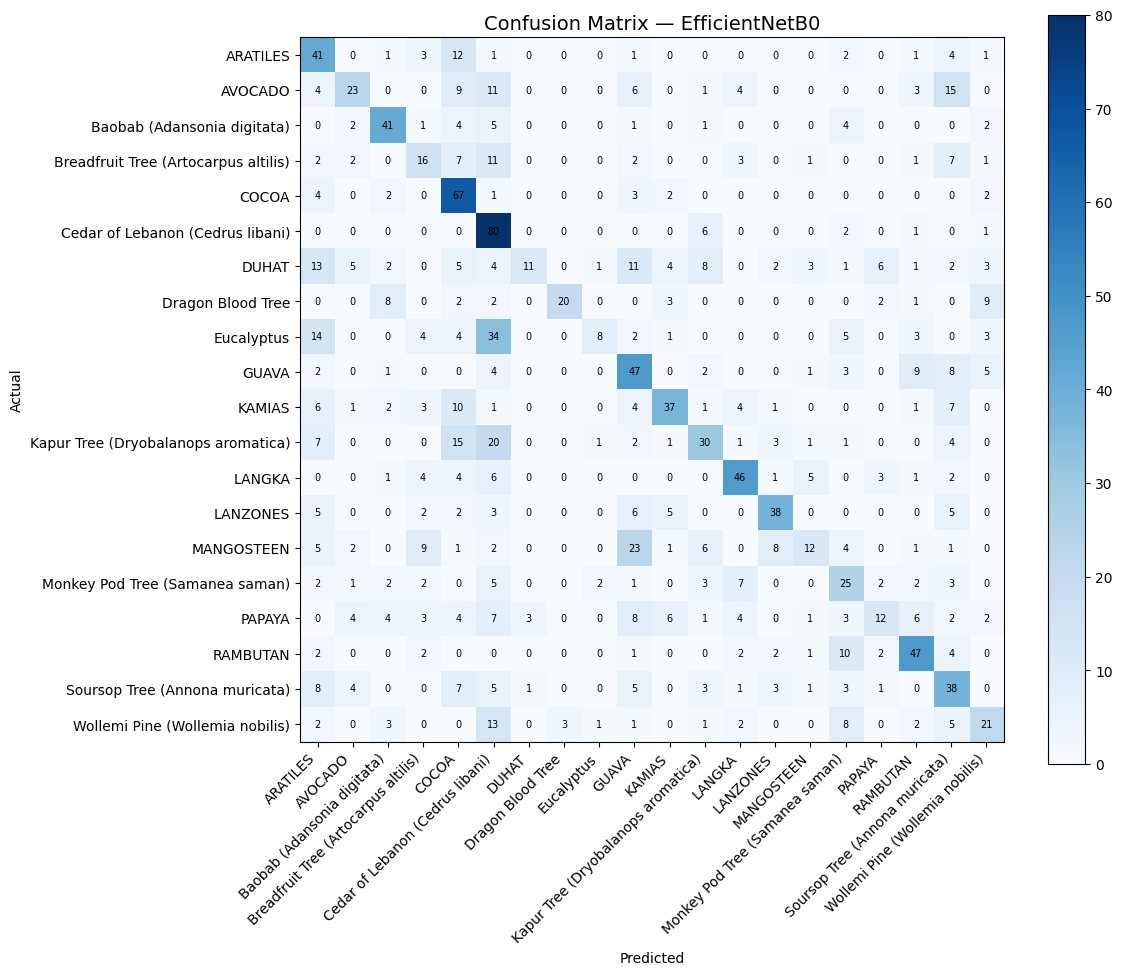

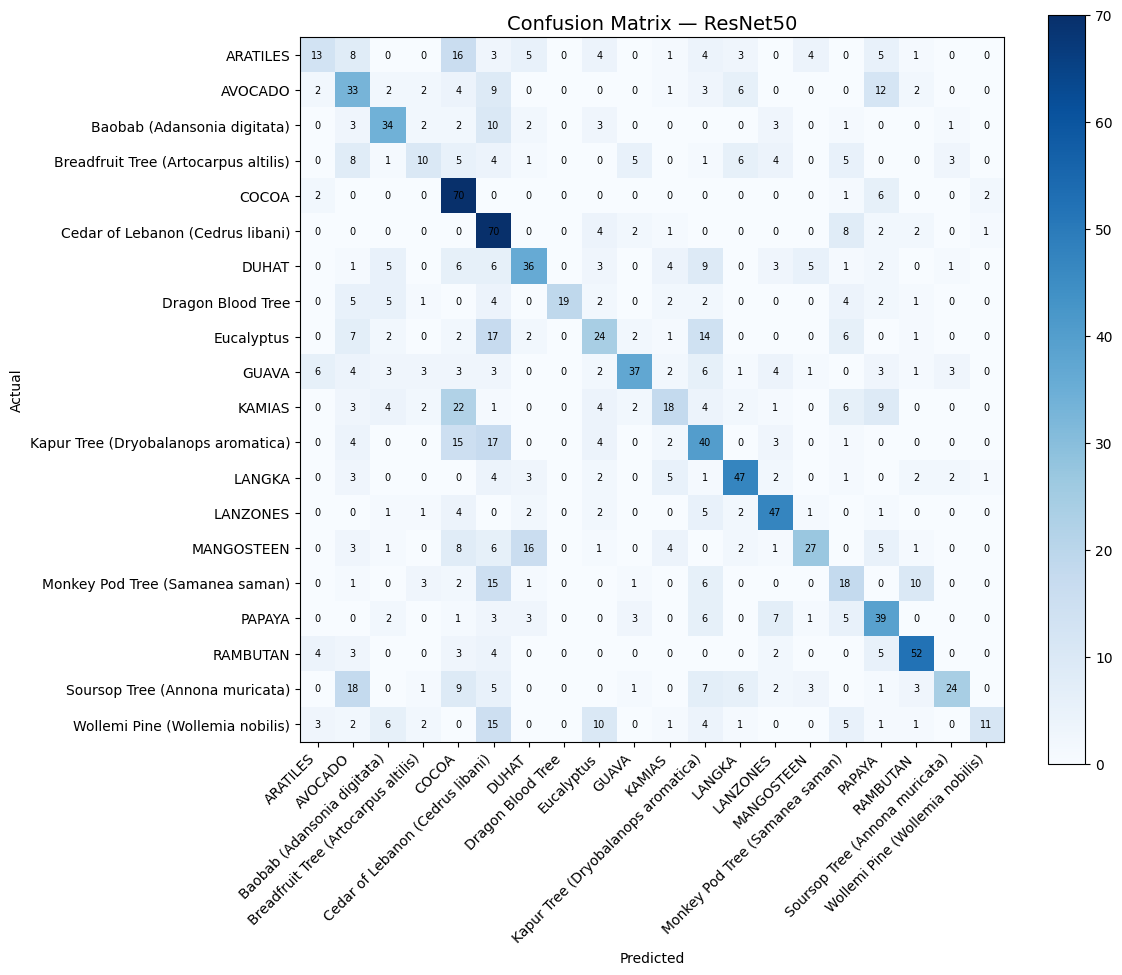

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    plt.imshow(cm, cmap='Blues')
    plt.title(title, fontsize=14)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=7)

    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/4th yr/{title.replace(' ','_')}_CM.png")
    plt.show()

# Run for all models
for name, res in results.items():
    plot_confusion_matrix(res['y_true'], res['y_pred'], f"Confusion Matrix — {name}")

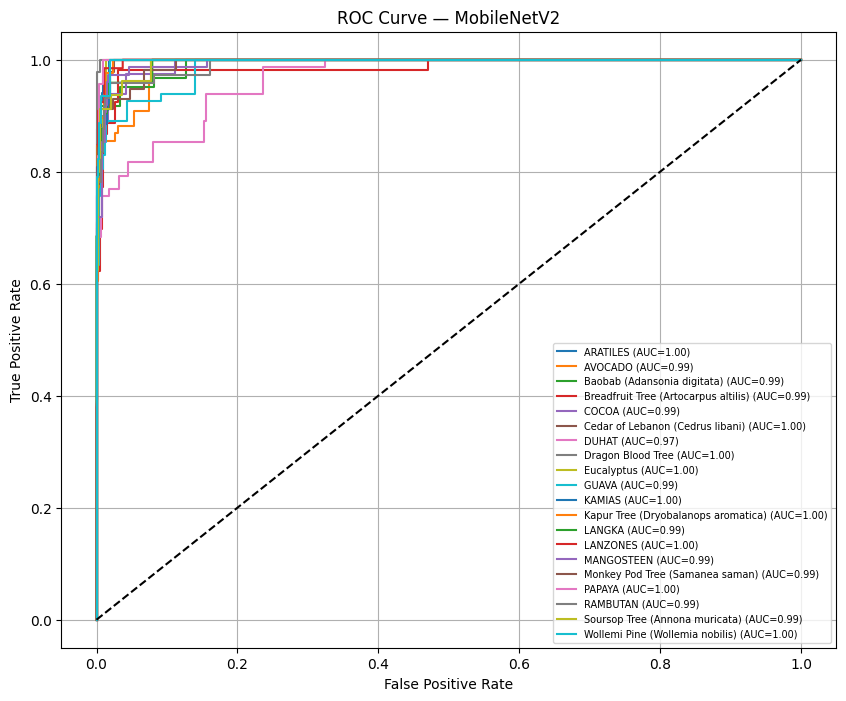

MobileNetV2 — Overall AUC Score: 0.9935


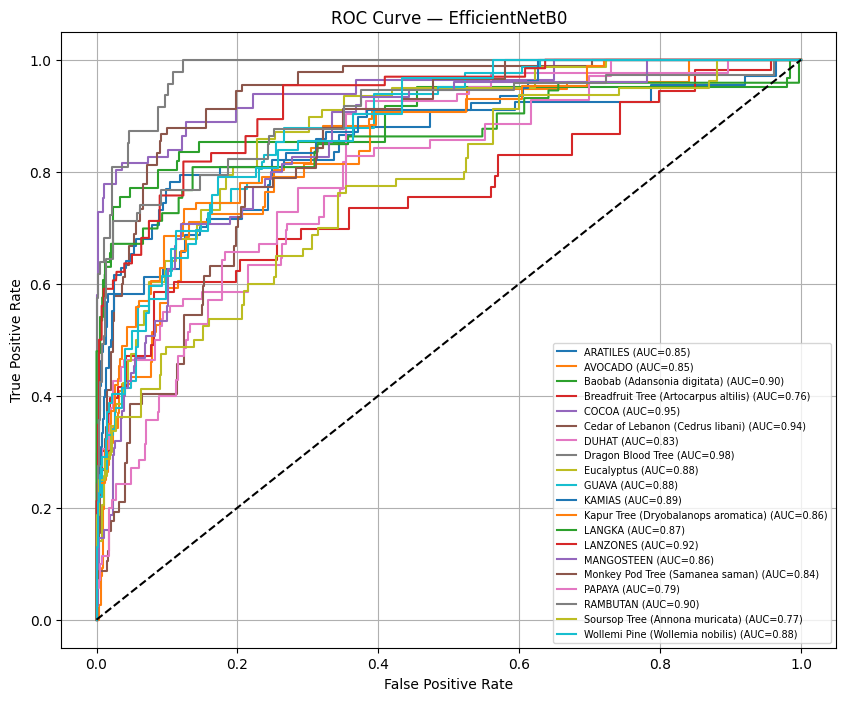

EfficientNetB0 — Overall AUC Score: 0.8696


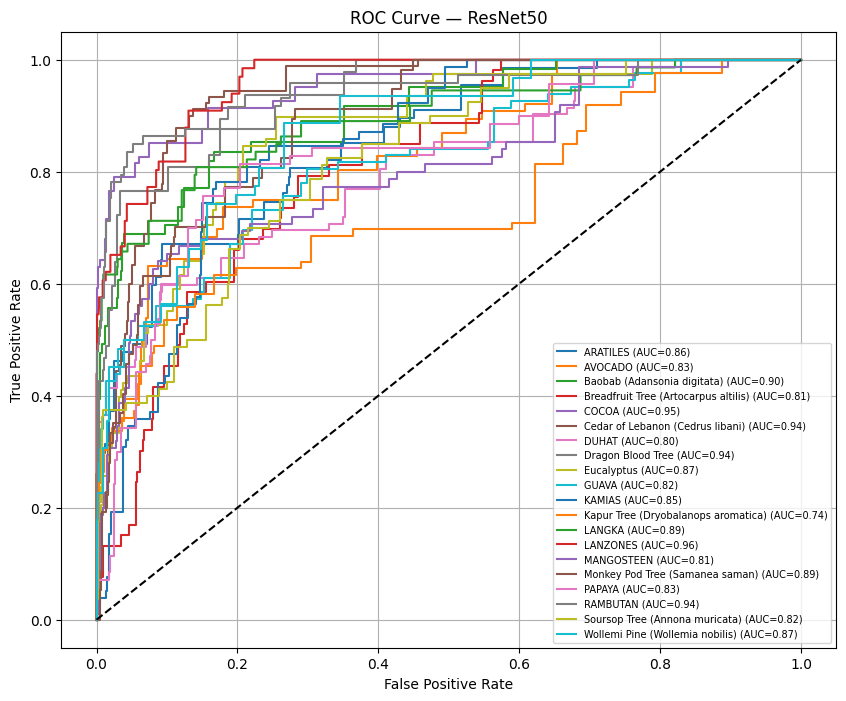

ResNet50 — Overall AUC Score: 0.8674


In [15]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

def plot_roc(y_true, y_prob, name):
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=range(n_classes))

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend(loc="lower right", fontsize=7)
    plt.grid(True)
    plt.savefig(f"/content/drive/MyDrive/4th yr/{name}_ROC.png")
    plt.show()

    # Overall AUC
    overall_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr')
    print(f"{name} — Overall AUC Score: {overall_auc:.4f}")
    return overall_auc

# Run for all models
auc_scores = {}
for name, res in results.items():
    auc_scores[name] = plot_roc(res['y_true'], res['y_prob'], name)

In [16]:
import tensorflow as tf
import numpy as np

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # If the layer is nested (e.g., inside a base model in Sequential),
    # we find the base model layer first.
    base_model = None
    for layer in model.layers:
        if hasattr(layer, 'layers'): # Check if it's a functional/sequential model inside
            try:
                layer.get_layer(last_conv_layer_name)
                base_model = layer
                break
            except ValueError:
                continue

    if base_model:
        grad_model = tf.keras.models.Model(
            [base_model.inputs],
            [base_model.get_layer(last_conv_layer_name).output, base_model.output]
        )
        # We need to pass the image through the layers before the base model (like Rescaling)
        # For your specific Sequential model: layer 0 is Rescaling
        x = model.layers[0](img_array)
        conv_outputs, predictions = grad_model(x)
    else:
        grad_model = tf.keras.models.Model(
            [model.inputs],
            [model.get_layer(last_conv_layer_name).output, model.output]
        )
        conv_outputs, predictions = grad_model(img_array)

    with tf.GradientTape() as tape:
        # Redoing the forward pass inside tape to track gradients
        if base_model:
            x = model.layers[0](img_array)
            conv_outputs, base_preds = grad_model(x)
            # Connect base_model output to the rest of the Sequential model
            preds = model.layers[2](base_preds) # GlobalAveragePooling
            preds = model.layers[3](preds)      # Dense
            preds = model.layers[4](preds)      # Dropout
            predictions = model.layers[5](preds)# Final Dense
        else:
            conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [17]:
# Find the last conv layer name for each model
last_conv_layers = {
    "MobileNetV2":   "Conv_1",          # last conv inside MobileNetV2
    "ResNet50":      "conv5_block3_out", # last conv block in ResNet50
    "EfficientNetB0":"top_conv",         # last conv in EfficientNetB0
    "VGG16":         "block5_conv3",     # last conv in VGG16
    "DenseNet121":   "conv5_block16_1_conv",
    "InceptionV3":   "mixed10",
}

# Verify by printing model layers (only if models were successfully trained):
if 'trained_models' in globals() and "MobileNetV2" in trained_models:
    for layer in trained_models["MobileNetV2"].layers:
        print(layer.name)
else:
    print("No trained models found. Please ensure the training cell (L30rDud7cy-m) runs successfully first.")

lambda
mobilenetv2_1.00_224
global_average_pooling2d
dense
dropout
dense_1


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_392']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_154']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


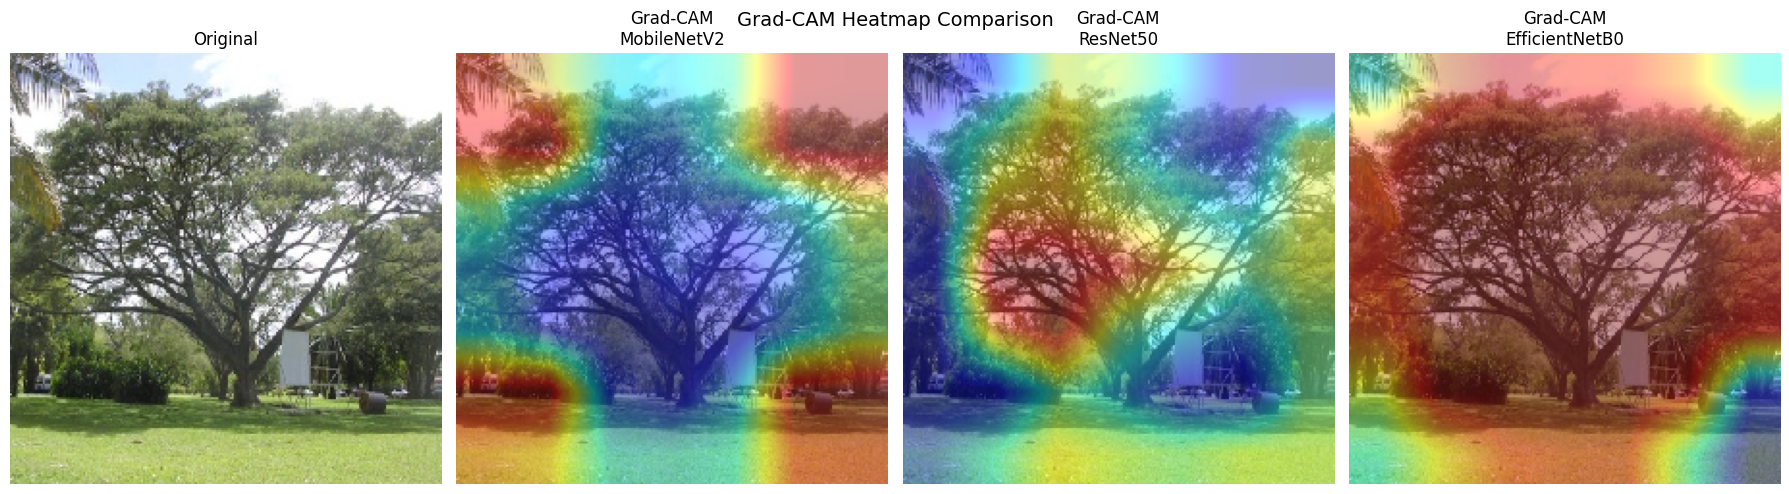

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Load a single test image (ensure this path is correct or use one from val_ds)
img_path = "/content/drive/MyDrive/4th yr/ImageDataset/test.jpg"
try:
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    model_names_to_compare = [n for n in ["MobileNetV2", "ResNet50", "EfficientNetB0"] if n in trained_models]
    fig, axes = plt.subplots(1, len(model_names_to_compare) + 1, figsize=(18, 5))

    # Show original
    axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis('off')

    for i, name in enumerate(model_names_to_compare):
        ax = axes[i+1]
        model = trained_models[name]
        conv_layer = last_conv_layers[name]

        try:
            heatmap = get_gradcam_heatmap(model, img_array, conv_layer)
            heatmap_resized = cv2.resize(np.uint8(255 * heatmap), (224, 224))
            heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

            # Create overlay
            img_np = np.uint8(255 * img_array[0])
            overlay = cv2.addWeighted(img_np, 0.6, heatmap_colored, 0.4, 0)

            ax.imshow(overlay); ax.set_title(f"Grad-CAM\n{name}"); ax.axis('off')
        except Exception as e:
            print(f"Could not generate Grad-CAM for {name}: {e}")
            ax.text(0.5, 0.5, f"Error: {name}", ha='center')
            ax.axis('off')

    plt.suptitle("Grad-CAM Heatmap Comparison", fontsize=14)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/4th yr/gradcam_comparison.png")
    plt.show()
except FileNotFoundError:
    print(f"Test image not found at {img_path}. Please check the path.")

In [20]:
from tensorflow.keras.models import load_model
import os

# Ensure the directory exists
os.makedirs("/content/drive/MyDrive/4th yr/", exist_ok=True)

if not trained_models:
    print("✘ No models found in 'trained_models'. Please run the training cell (L30rDud7cy-m) first.")
else:
    for name, model in trained_models.items():
        save_path = f"/content/drive/MyDrive/4th yr/{name}_model.keras"
        model.save(save_path)
        print(f"✔ Saved: {save_path}")

    # Verify one model loads correctly - using MobileNetV2 as a test
    # We use safe_mode=False because the model contains Lambda layers (preprocessing)
    verification_path = "/content/drive/MyDrive/4th yr/MobileNetV2_model.keras"
    if os.path.exists(verification_path):
        try:
            test_load = load_model(verification_path, safe_mode=False)
            print(f"✔ Verification: {verification_path} loaded successfully with safe_mode=False")
        except Exception as e:
            print(f"✘ Verification Failed during loading: {e}")
    else:
        print(f"✘ Verification Failed: Could not find file at {verification_path}")

✔ Saved: /content/drive/MyDrive/4th yr/MobileNetV2_model.keras
✔ Saved: /content/drive/MyDrive/4th yr/EfficientNetB0_model.keras
✔ Saved: /content/drive/MyDrive/4th yr/ResNet50_model.keras
✔ Verification: /content/drive/MyDrive/4th yr/MobileNetV2_model.keras loaded successfully with safe_mode=False


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{'Model':<20} {'Val Acc':>8} {'AUC':>8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 70)

for name, res in results.items():
    yt, yp, yprob = res['y_true'], res['y_pred'], res['y_prob']
    p  = precision_score(yt, yp, average='macro', zero_division=0)
    r  = recall_score(yt, yp, average='macro', zero_division=0)
    f1 = f1_score(yt, yp, average='macro', zero_division=0)
    val_acc = sum(yt == yp) / len(yt)
    auc = auc_scores.get(name, 0)
    print(f"{name:<20} {val_acc:>8.4f} {auc:>8.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f}")

Model                 Val Acc      AUC  Precision   Recall       F1
----------------------------------------------------------------------
MobileNetV2            0.9381   0.9935     0.9446   0.9401   0.9407
EfficientNetB0         0.4593   0.8696     0.5097   0.4548   0.4379
ResNet50               0.4656   0.8674     0.5217   0.4546   0.4508
